In [ ]:
# sabse pehle dataset chaiye hoga to train the model on 
# step - 1 - import sari libraries that we need 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score # finally score check karne ke liye 

iris = load_iris()
X = iris.data
Y = iris.target
print(X.shape)
print(Y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2, # 20% percent test karne ke liye use hoga 
    # 80% train karne ke liye
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train)
print(y_test)
model = LogisticRegression(max_iter=200)
model.fit(X_train,y_train) # pass both x and y train wala data to train the model on 
y_pred = model.predict(X_test) # predictions by the model on the testing data
print(y_test) # actual output
accuracy = accuracy_score(y_test,y_pred)


(150, 4)
(150,)
(120, 4)
(30, 4)
[0 0 1 0 0 2 1 0 0 0 2 1 1 0 0 1 2 2 1 2 1 2 1 0 2 1 0 0 0 1 2 0 0 0 1 0 1
 2 0 1 2 0 2 2 1 1 2 1 0 1 2 0 0 1 1 0 2 0 0 1 1 2 1 2 2 1 0 0 2 2 0 0 0 1
 2 0 2 2 0 1 1 2 1 2 0 2 1 2 1 1 1 0 1 1 0 1 2 2 0 1 2 2 0 2 0 1 2 2 1 2 1
 1 2 2 0 1 2 0 1 2]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy -> 1.0


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

<Figure size 1500x800 with 0 Axes>

In [ ]:
# sabse pehle dataset chaiye hoga to train the model on 
# step - 1 - import sari libraries that we need 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score # finally score check karne ke liye 

iris = load_iris()
X = iris.data
Y = iris.target
print(X.shape)
print(Y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2, # 20% percent test karne ke liye use hoga 
    # 80% train karne ke liye
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train)
print(y_test)
model = LogisticRegression(max_iter=200)
model.fit(X_train,y_train) # pass both x and y train wala data to train the model on 
y_pred = model.predict(X_test) # predictions by the model on the testing data
print(y_test) # actual output
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy ->",accuracy)

In [ ]:
# training on the titanic dataset
import seaborn as sns
df = sns.load_dataset('titanic')
df.to_csv('titanic.csv',index=False)
# survival prediction of a yatri hoga yaha par 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv('titanic.csv')
print(df.shape)
print(df.head())
print(df.columns)
print(df.isnull().sum())
# dataframe mai sirf wahi columns rakhege jo kaam ke hai
df = df[['survived','pclass','sex','age','fare']]
print(df.head())
df['age'] = df['age'].fillna(df['age'].median()) # jaha age mai na data hai waha median age dal dena hai 
df = df.dropna() # remove sari rows having na values in them 
print(df.isnull().sum())
df['sex'] = df['sex'].map({'male' : 0 , 'female' : 1}) # model numbers expect karta hai to replace male female with 0 and 1
print(df.head())
X = df[['pclass','sex','age','fare']]
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy->",accuracy)
# custom passanger testing 
sample = pd.DataFrame([[1,1,25,100]], columns=['pclass','sex','age','fare'])
prediction = model.predict(sample)
print("kya ye passanger bachega ? ", "Yes" if prediction[0] == 1 else "NO")

Decision tree ki accuracy ->  0.7988826815642458
Random forest ki accuracy :  0.8156424581005587
Comparison
LogisticRegression ki accuracy : 
DecisionTreeClassifier ki accuracy : 0.7988826815642458
Random Forest ki accuracy :  0.8156424581005587


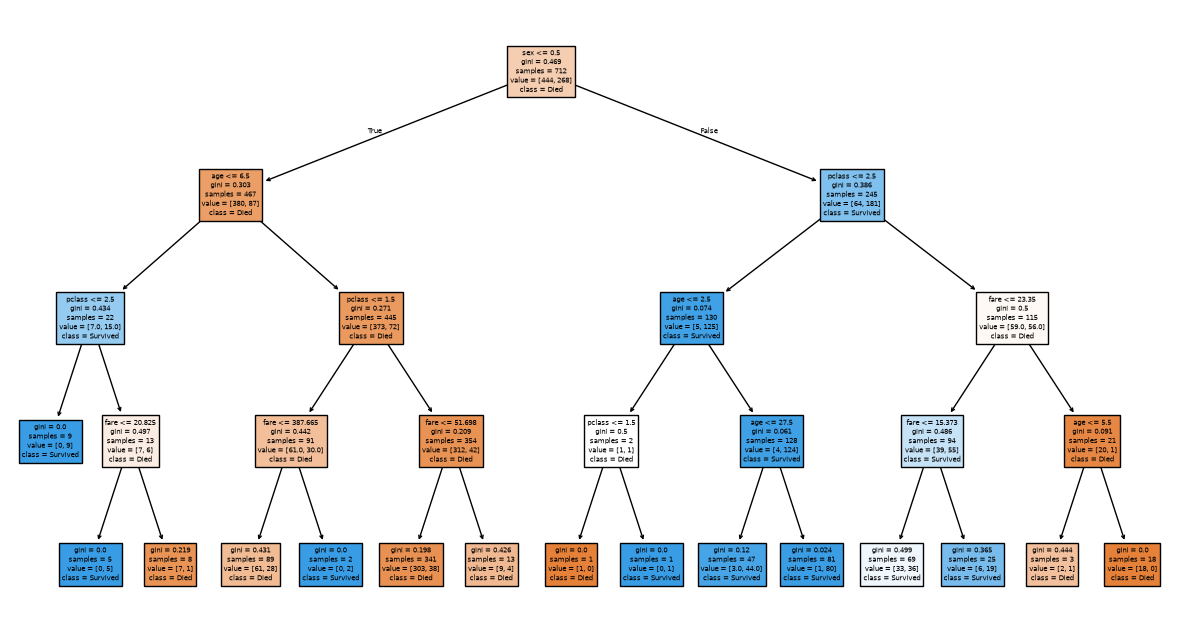

In [ ]:
# same titanic prediction using different models 
# 1) DecisionTreeClassifier
# 2) RandomForestClassifier
# steps jo har case mai same rahege
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv('titanic.csv')
df = df[['survived','pclass','sex','age','fare']]
df['age'] = df['age'].fillna(df['age'].median())
df = df.dropna()
df['sex'] = df['sex'].map({'male' : 0, 'female' : 1})
X = df[['pclass','sex','age','fare']]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# pehla model decision tree
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=4, # is model mai tree kitni depth tak ja raha hai important hota hai 
    # to prevent any form of overfitting possible here ( model dataset memorize kar leta hai to dataset par bahut acchi accuracy deta hai )
    # but baki jagah par utni acchi accuracy nahi deta hai 
    random_state=42
)
tree_model.fit(X_train,y_train)
tree_pred = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test,tree_pred)
print("Decision tree ki accuracy -> ", tree_acc)
 # Model - 2 : Random Forest Model 
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)
forest_model.fit(X_train,y_train)
forest_pred = forest_model.predict(X_test)
acc = accuracy_score(forest_pred,y_test)
print("Random forest ki accuracy : ", acc)


# teeno models ka apas mai comparison yaha par 
print("Comparison")
print("LogisticRegression ki accuracy : ")
print("DecisionTreeClassifier ki accuracy :", tree_acc)
print("Random Forest ki accuracy : ", acc)
#scatter plot of the data
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(tree_model,feature_names=X.columns,class_names=['Died','Survived'],filled=True)
plt.show()

LogisticRegression   accuracy:0.788
Decision Tree        accuracy:0.777
Random Forest        accuracy:0.799


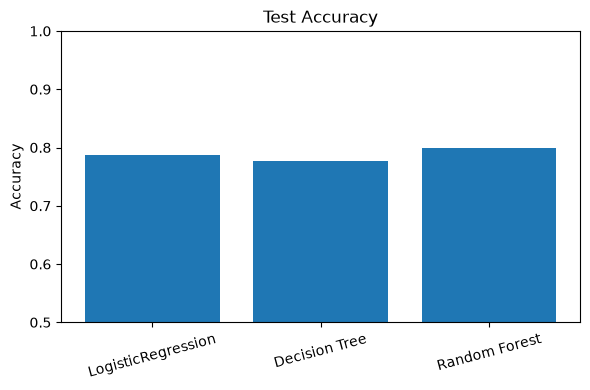

In [28]:
# titanic dataset all 3 types of models used ->
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay

if not os.path.exists('titanic.csv'):
    sns.load_dataset('titanic.csv').to_csv('titanic.csv',index=False)

df = pd.read_csv('titanic.csv')

# data ko clean karne ke steps to handle only the required data
df = df[['survived','pclass','sex','age','fare']] # siry yahi cols rakhne hai
df['age'] = df['age'].fillna(df['age'].median()) # replace age not filled with median age
df = df.dropna() # drop sari na values
df['sex'] = df['sex'].map({'male' : 0, 'female' : 1}) # replace gender text with binary numbers

X = df[['pclass','sex','age','fare']]
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)
models = {
    'LogisticRegression' : LogisticRegression(max_iter=1000),
    'Decision Tree' : DecisionTreeClassifier(max_depth=4,random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100,max_depth=4,random_state=4)
}
accuracies = {}
for name, model in models.items():
    model.fit(X_train,y_train)
    accuracies[name] = accuracy_score(y_test,model.predict(X_test))
    print(f"{name:20s} accuracy:{accuracies[name]:.3f}")

plt.figure(figsize=(6,4))
plt.bar(accuracies.keys(),accuracies.values())
plt.ylim(0.5,1.0)
plt.title("Test Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

LogisticRegression   accuracy:0.788
Decision Tree        accuracy:0.777
Random Forest        accuracy:0.799


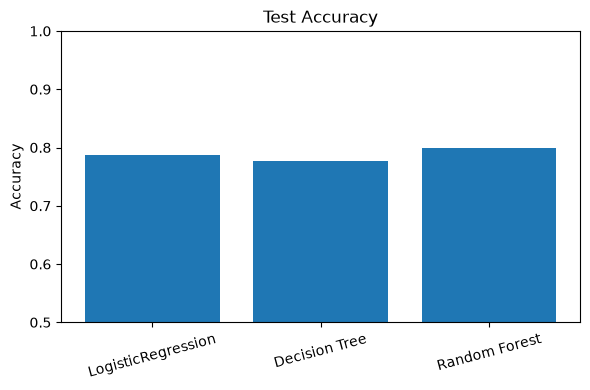

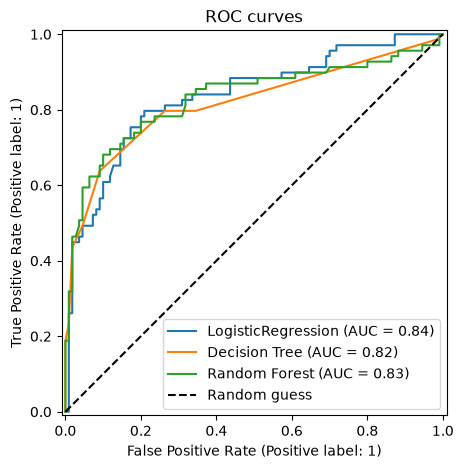

In [30]:
# titanic dataset all 3 types of models used ->
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay

if not os.path.exists('titanic.csv'):
    sns.load_dataset('titanic.csv').to_csv('titanic.csv',index=False)

df = pd.read_csv('titanic.csv')

# data ko clean karne ke steps to handle only the required data
df = df[['survived','pclass','sex','age','fare']] # siry yahi cols rakhne hai
df['age'] = df['age'].fillna(df['age'].median()) # replace age not filled with median age
df = df.dropna() # drop sari na values
df['sex'] = df['sex'].map({'male' : 0, 'female' : 1}) # replace gender text with binary numbers

X = df[['pclass','sex','age','fare']]
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)
models = {
    'LogisticRegression' : LogisticRegression(max_iter=1000),
    'Decision Tree' : DecisionTreeClassifier(max_depth=4,random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100,max_depth=4,random_state=4)
}
accuracies = {}
for name, model in models.items():
    model.fit(X_train,y_train)
    accuracies[name] = accuracy_score(y_test,model.predict(X_test))
    print(f"{name:20s} accuracy:{accuracies[name]:.3f}")

plt.figure(figsize=(6,4))
plt.bar(accuracies.keys(),accuracies.values())
plt.ylim(0.5,1.0)
plt.title("Test Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
#plt.show()

# confusion matrix plot ( actually mai model ne galti kaha ki )
fig,ax = plt.subplots(figsize=(6,5))
for name,model in models.items():
    RocCurveDisplay.from_estimator(model,X_test,y_test,ax=ax,name=name)
ax.plot([0,1],[0,1],'k--',label='Random guess')
ax.set_title("ROC curves")
ax.legend()
plt.show()


Logistic Regression  accuracy: 0.788
Decision Tree        accuracy: 0.777
Random Forest        accuracy: 0.804


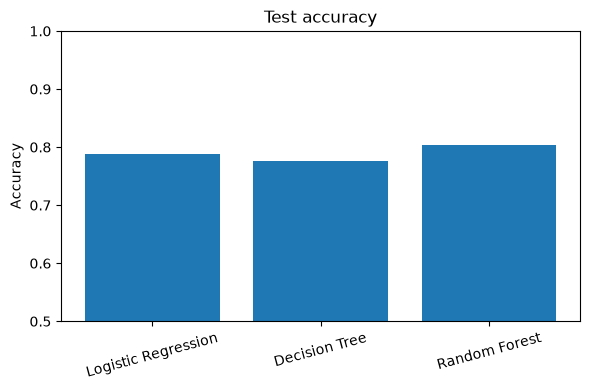

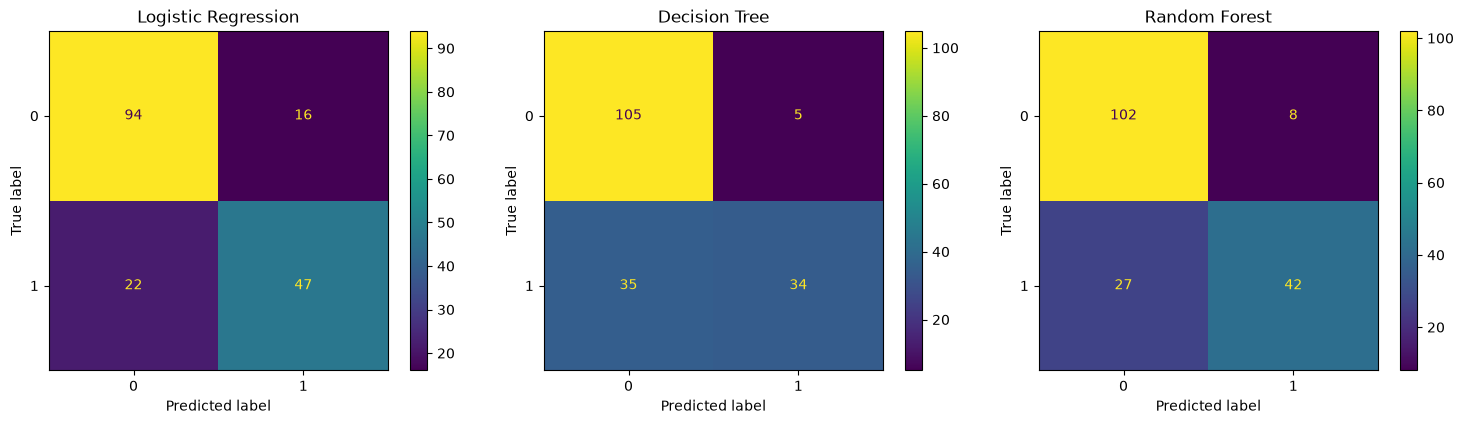

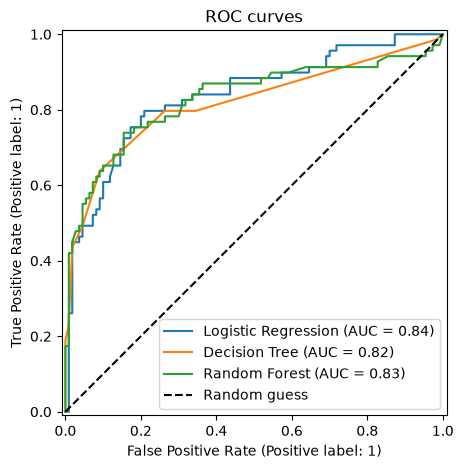

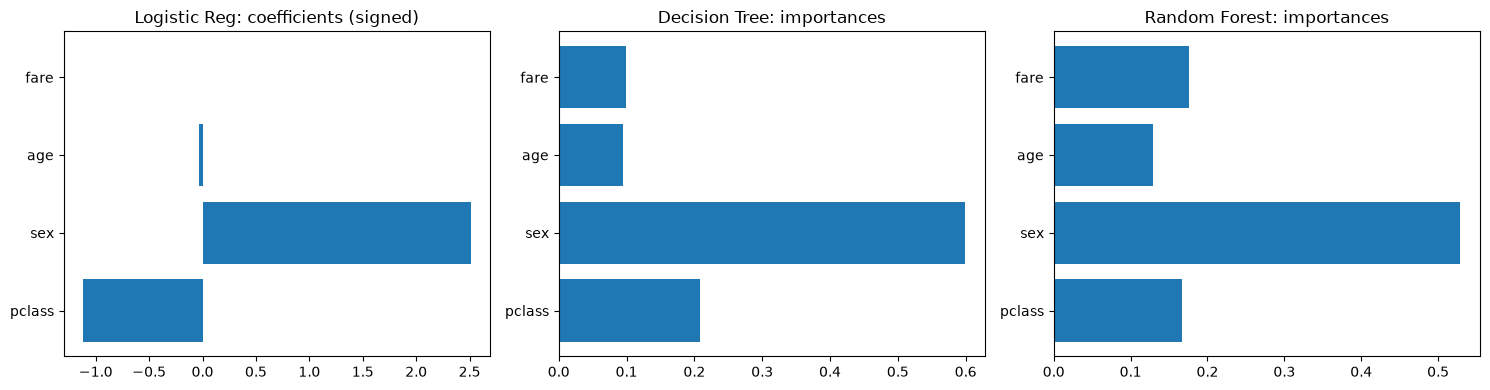

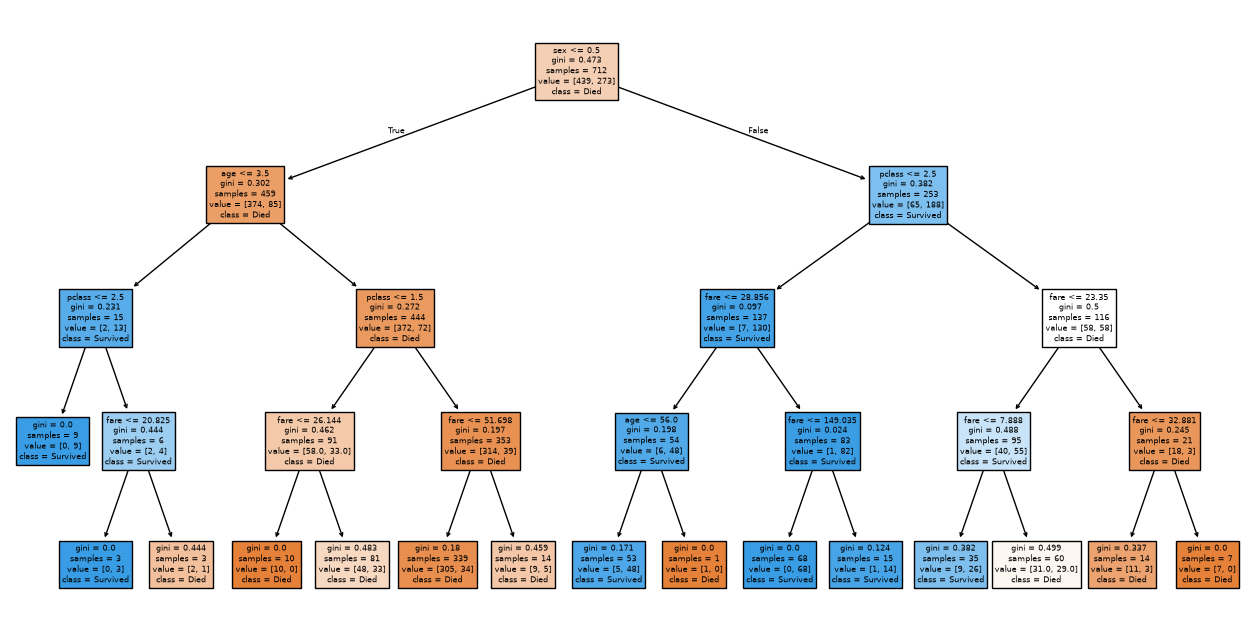

In [34]:
# ============================================================
# Titanic survival prediction: 3 models, accuracy + diagnostic plots
# Install once: pip install pandas seaborn scikit-learn matplotlib
# ============================================================
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay

# ---- 1. Get the dataset (download once via seaborn, then reuse the CSV) ----
if not os.path.exists('titanic.csv'):
    sns.load_dataset('titanic').to_csv('titanic.csv', index=False)

df = pd.read_csv('titanic.csv')

# ---- 2. Clean ----
df = df[['survived', 'pclass', 'sex', 'age', 'fare']]      # keep useful columns
df['age'] = df['age'].fillna(df['age'].median())           # fill missing ages
df = df.dropna()                                           # drop any leftover NaN rows
df['sex'] = df['sex'].map({'male': 0, 'female': 1})        # text -> numbers

# ---- 3. Features / label / split ----
X = df[['pclass', 'sex', 'age', 'fare']]
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---- 4. Define, train, and score all three models ----
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42),
}

accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    accuracies[name] = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:20s} accuracy: {accuracies[name]:.3f}")

# ---- 5. PLOT: accuracy comparison ----
plt.figure(figsize=(6, 4))
plt.bar(accuracies.keys(), accuracies.values())
plt.ylim(0.5, 1.0)
plt.title("Test accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# ---- 6. PLOT: confusion matrices (where does each model make mistakes?) ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

# ---- 7. PLOT: ROC curves on one graph (higher AUC = better) ----
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.set_title("ROC curves")
ax.legend()
plt.show()

# ---- 8. PLOT: what each model relied on ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cols = list(X.columns)
axes[0].barh(cols, models['Logistic Regression'].coef_[0])
axes[0].set_title("Logistic Reg: coefficients (signed)")
axes[1].barh(cols, models['Decision Tree'].feature_importances_)
axes[1].set_title("Decision Tree: importances")
axes[2].barh(cols, models['Random Forest'].feature_importances_)
axes[2].set_title("Random Forest: importances")
plt.tight_layout()
plt.show()

# ---- 9. PLOT: the decision tree itself ----
plt.figure(figsize=(16, 8))
plot_tree(models['Decision Tree'], feature_names=cols,
          class_names=['Died', 'Survived'], filled=True)
plt.show()